# Chapter 30: The AI as Policy Searcher

*Systems Thinking with AI* by Jason Karpeles

Rank by the worst case among the policies that satisfy every constraint, and say what was excluded.

**Goal.** Four experiments on three named growth policies run against the same uncertainty draws. See the best average excluded by a ceiling, compare checking every draw with checking the average, watch separate draws reverse a close comparison, and see what happens when no policy is admissible.

**Demonstrations**

1. The best average is excluded
2. Every draw, not the average
3. Same draws, every policy
4. When no policy is admissible

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/30-policy-search/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/30-policy-search/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_13_expressions/code/expressions.py`

In [2]:
%%module chapters.chapter_13_expressions.code.expressions
"""Evaluate a model's algebra without granting it the power to run arbitrary code.

A declarative model spec carries expressions as text. Handing that text to eval()
gives whoever wrote the spec the ability to do anything the process can do. This
module parses to a syntax tree, walks it against a whitelist, and refuses anything
outside it.
"""

import ast
import math
from collections.abc import Callable

ALLOWED_FUNCTIONS: dict[str, Callable[..., float]] = {
    "min": min,
    "max": max,
    "abs": abs,
    "exp": math.exp,
    "log": math.log,
    "sqrt": math.sqrt,
}

_ALLOWED_NODES = (
    ast.Expression, ast.BinOp, ast.UnaryOp, ast.Name, ast.Load, ast.Constant, ast.Call,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow, ast.USub, ast.UAdd, ast.Mod,
    ast.Compare, ast.Lt, ast.LtE, ast.Gt, ast.GtE, ast.Eq, ast.NotEq, ast.IfExp,
)


class UnsafeExpression(ValueError):
    """Raised when an expression asks for something the whitelist does not permit."""


def parse(text: str, functions: dict[str, Callable[..., float]] | None = None) -> ast.Expression:
    """Parse an expression and reject every construct outside the whitelist.

    `functions` names what may be called. It defaults to this module's own table,
    and Chapter 23 passes its approved registry in instead, so a model calls what
    a person approved rather than what this file happens to import.
    """
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    if not text.strip():
        raise UnsafeExpression("an expression cannot be empty")
    try:
        tree = ast.parse(text, mode="eval")
    except SyntaxError as exc:
        raise UnsafeExpression(f"not a valid expression: {exc.msg}") from exc
    for node in ast.walk(tree):
        if not isinstance(node, _ALLOWED_NODES):
            raise UnsafeExpression(f"{type(node).__name__} is not permitted in a model expression")
        if isinstance(node, ast.Call):
            if not isinstance(node.func, ast.Name):
                raise UnsafeExpression("only direct calls to whitelisted functions are permitted")
            if node.func.id not in allowed:
                raise UnsafeExpression(f"'{node.func.id}' is not an allowed function")
            if node.keywords:
                raise UnsafeExpression("keyword arguments are not permitted")
        if isinstance(node, ast.Constant) and not isinstance(node.value, (int, float, bool)):
            raise UnsafeExpression("only numeric constants are permitted")
    return tree


def variables(text: str, functions: dict[str, Callable[..., float]] | None = None) -> set[str]:
    """Every name an expression reads. The model's dependency edges come from here."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    return {n.id for n in ast.walk(tree) if isinstance(n, ast.Name) and n.id not in allowed}


def evaluate(text: str, values: dict[str, float],
             functions: dict[str, Callable[..., float]] | None = None) -> float:
    """Evaluate a whitelisted expression against a supplied set of named values."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    needed = variables(text, allowed)
    missing = needed - set(values)
    if missing:
        raise ValueError(f"no value supplied for: {sorted(missing)}")
    scope: dict[str, object] = {**allowed, **values}
    return eval(compile(tree, "<model>", "eval"), {"__builtins__": {}}, scope)  # noqa: S307


`chapters/chapter_20_model_document/code/document.py`

In [3]:
%%module chapters.chapter_20_model_document.code.document
"""A model as structured data: validated, versioned, and hashable.

An imperative model is a program. A change to it is a diff of code, and whether
the change altered the model's meaning requires reading the code. A declarative
model is a document, and a change to it is a diff of assumptions.
"""

import hashlib
import json
import re
from dataclasses import MISSING, asdict, dataclass, field, fields

from chapters.chapter_13_expressions.code.expressions import UnsafeExpression, variables

ID_PATTERN = re.compile(r"^[a-z][a-z0-9_]*$")
KINDS = ("stock", "flow", "auxiliary", "parameter", "perception", "lookup", "delay")


@dataclass(frozen=True)
class Variable:
    """One named quantity, with everything needed to place it in the model."""

    id: str
    kind: str
    unit: str
    equation: str = ""
    value: float | None = None
    evidence: str = "assumed"
    note: str = ""
    target: str = ""   # for a flow: which stock it moves
    sign: int = 1      # +1 adds to the target, -1 removes from it
    points: tuple[tuple[float, float], ...] = ()   # for a lookup: the observed shape
    delay_time: float | None = None                # for a delay: its mean, in horizon units

    def __post_init__(self) -> None:
        if not ID_PATTERN.match(self.id):
            raise ValueError(f"'{self.id}' is not a canonical id: lower case, digits, underscores")
        if self.kind not in KINDS:
            raise ValueError(f"kind must be one of {KINDS}")
        if not self.unit.strip():
            raise ValueError(f"'{self.id}' has no unit")
        if self.kind in ("stock", "parameter") and self.value is None:
            raise ValueError(f"'{self.id}' is a {self.kind} and needs a value")
        if self.kind in ("flow", "auxiliary") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation")
        if self.sign not in (1, -1):
            raise ValueError("sign must be +1 or -1")
        if self.target and self.kind != "flow":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot target a stock")
        if self.kind in ("lookup", "delay") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation for its input")
        if self.points and self.kind != "lookup":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry lookup points")
        if self.kind == "lookup":
            if len(self.points) < 2:
                raise ValueError(f"lookup '{self.id}' needs at least two points")
            xs = [x for x, _ in self.points]
            if xs != sorted(xs) or len(set(xs)) != len(xs):
                raise ValueError(f"lookup '{self.id}' needs points with increasing x")
        if self.delay_time is not None and self.kind != "delay":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry a delay time")
        if self.kind == "delay" and (self.delay_time is None or self.delay_time <= 0):
            raise ValueError(f"delay '{self.id}' needs a positive delay_time")


@dataclass
class ModelDocument:
    """The whole model, as data. Nothing here executes."""

    name: str
    version: str
    variables: list[Variable] = field(default_factory=list)
    horizon: int = 1
    horizon_unit: str = "week"
    time_step: float = 1.0

    def __post_init__(self) -> None:
        if not re.match(r"^\d+\.\d+\.\d+$", self.version):
            raise ValueError("version must be semantic: major.minor.patch")
        ids = [v.id for v in self.variables]
        duplicates = {i for i in ids if ids.count(i) > 1}
        if duplicates:
            raise ValueError(f"duplicate ids: {sorted(duplicates)}")
        if self.time_step <= 0 or self.horizon < 1:
            raise ValueError("time_step must be positive and horizon at least 1")

    def by_id(self, name: str) -> Variable:
        for v in self.variables:
            if v.id == name:
                return v
        raise KeyError(f"no variable '{name}' in this model")

    @staticmethod
    def _asserted(variable: "Variable") -> dict:
        """A variable's fields minus the ones sitting at their default.

        A field at its default asserts nothing, so it stays out of the canonical
        form. That is what lets the schema gain a field without changing the hash
        of every document written before it existed.
        """
        defaults = {
            f.name: (f.default if f.default is not MISSING else None) for f in fields(variable)
        }
        return {k: v for k, v in asdict(variable).items() if v != defaults.get(k)}

    def canonical(self) -> str:
        """A stable text form: keys sorted, variables ordered, no incidental whitespace."""
        payload = {
            "name": self.name,
            "horizon": self.horizon,
            "horizon_unit": self.horizon_unit,
            "time_step": self.time_step,
            "variables": sorted(
                (self._asserted(v) for v in self.variables), key=lambda d: d["id"]
            ),
        }
        return json.dumps(payload, sort_keys=True, separators=(",", ":"))

    def hash(self) -> str:
        """Content hash of the model's meaning. Excludes the version deliberately."""
        return hashlib.sha256(self.canonical().encode()).hexdigest()[:16]


def validate(document: ModelDocument) -> list[str]:
    """Every problem findable without running anything."""
    problems = []
    known = {v.id for v in document.variables}
    for variable in document.variables:
        if variable.kind == "parameter" and variable.evidence == "observed" and not variable.note:
            problems.append(f"'{variable.id}' claims observation with no source note")
        if variable.equation:
            try:
                referenced = variables(variable.equation)
            except UnsafeExpression as exc:
                problems.append(f"'{variable.id}' has an invalid expression: {exc}")
            else:
                for name in sorted(referenced - known):
                    problems.append(f"'{variable.id}' references undefined '{name}'")
    stocks = {v.id for v in document.variables if v.kind == "stock"}
    for variable in document.variables:
        if variable.kind == "flow":
            if not variable.target:
                problems.append(f"flow '{variable.id}' does not say which stock it moves")
            elif variable.target not in stocks:
                problems.append(f"flow '{variable.id}' targets '{variable.target}', not a stock")
    for stock in sorted(stocks):
        moved = [v for v in document.variables if v.kind == "flow" and v.target == stock]
        if not moved:
            problems.append(f"stock '{stock}' has no flow: nothing can change it")
    if not stocks and not any(v.kind == "delay" for v in document.variables):
        problems.append("no stock or delay: nothing in this model carries state")
    return problems


def diff(old: ModelDocument, new: ModelDocument) -> dict[str, object]:
    """What changed between two versions, in the model's own terms."""
    old_ids = {v.id: v for v in old.variables}
    new_ids = {v.id: v for v in new.variables}
    changed = [
        i for i in old_ids.keys() & new_ids.keys() if asdict(old_ids[i]) != asdict(new_ids[i])
    ]
    return {
        "added": sorted(new_ids.keys() - old_ids.keys()),
        "removed": sorted(old_ids.keys() - new_ids.keys()),
        "changed": sorted(changed),
        "fields": {
            f.name: {"before": getattr(old, f.name), "after": getattr(new, f.name)}
            for f in fields(old)
            if f.name != "variables" and getattr(old, f.name) != getattr(new, f.name)
        },
        "variables": {
            name: {"before": asdict(old_ids[name]) if name in old_ids else None,
                   "after": asdict(new_ids[name]) if name in new_ids else None}
            for name in sorted(set(changed) | (old_ids.keys() ^ new_ids.keys()))
        },
    }


`chapters/chapter_15_lookups/code/lookup.py`

In [4]:
%%module chapters.chapter_15_lookups.code.lookup
"""A lookup that interpolates inside its evidence and refuses outside it."""

from bisect import bisect_left


class OutsideDomain(ValueError):
    """Raised when a lookup is asked about a region no observation covers."""


class Lookup:
    """Piecewise-linear interpolation over observed points, with a closed domain."""

    def __init__(self, points: list[tuple[float, float]], name: str = "lookup") -> None:
        if len(points) < 2:
            raise ValueError("a lookup needs at least two observed points")
        ordered = sorted(points)
        xs = [x for x, _ in ordered]
        if len(set(xs)) != len(xs):
            raise ValueError("a lookup cannot hold two values for the same input")
        self.name = name
        self.xs = xs
        self.ys = [y for _, y in ordered]

    @property
    def domain(self) -> tuple[float, float]:
        return self.xs[0], self.xs[-1]

    def __call__(self, x: float) -> float:
        low, high = self.domain
        # A solver that lands on a domain end arrives a few machine epsilons past
        # it. Refusing that is refusing arithmetic, not refusing extrapolation, so
        # an input within a hair of an end is snapped to it and anything further
        # out is still refused.
        tolerance = 1e-9 * max(1.0, abs(low), abs(high))
        if low - tolerance <= x < low:
            x = low
        elif high < x <= high + tolerance:
            x = high
        if not low <= x <= high:
            raise OutsideDomain(
                f"{self.name} was asked about {x}, outside its observed domain [{low}, {high}]"
            )
        i = bisect_left(self.xs, x)
        if self.xs[i] == x:
            return self.ys[i]
        x0, x1, y0, y1 = self.xs[i - 1], self.xs[i], self.ys[i - 1], self.ys[i]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    def is_monotonic(self) -> bool:
        """True when the relationship never reverses direction."""
        up = all(b >= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        down = all(b <= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        return up or down

    def is_bounded_by(self, low: float, high: float) -> bool:
        return all(low <= y <= high for y in self.ys)


def fit_polynomial(points: list[tuple[float, float]], degree: int) -> list[float]:
    """Least-squares polynomial coefficients, lowest order first. Deliberately naive."""
    n = degree + 1
    if len(points) < n:
        raise ValueError("not enough points for that degree")
    xs = [x for x, _ in points]
    ys = [y for _, y in points]
    a = [[sum(x ** (i + j) for x in xs) for j in range(n)] for i in range(n)]
    b = [sum(y * x**i for x, y in zip(xs, ys, strict=True)) for i in range(n)]
    for col in range(n):
        pivot = max(range(col, n), key=lambda r: abs(a[r][col]))
        if abs(a[pivot][col]) < 1e-12:
            raise ValueError("the fit is singular at this degree")
        a[col], a[pivot] = a[pivot], a[col]
        b[col], b[pivot] = b[pivot], b[col]
        for r in range(n):
            if r == col:
                continue
            factor = a[r][col] / a[col][col]
            a[r] = [x - factor * y for x, y in zip(a[r], a[col], strict=True)]
            b[r] -= factor * b[col]
    return [b[i] / a[i][i] for i in range(n)]


def evaluate_polynomial(coefficients: list[float], x: float) -> float:
    """A fit will answer any question asked of it. That is the problem."""
    return sum(c * x**i for i, c in enumerate(coefficients))


`chapters/chapter_08_causal_graph/code/graph.py`

In [5]:
%%module chapters.chapter_08_causal_graph.code.graph
"""A causal graph whose links carry evidence status and time semantics.

A link with no evidence status and no delay is a drawing. This module refuses to
treat one as a finding.
"""

from dataclasses import dataclass

EVIDENCE_LEVELS = ("observed", "inferred", "assumed", "proposed")


@dataclass(frozen=True)
class Link:
    """One causal claim: source, target, sign, how it is known, and whether it is delayed."""

    source: str
    target: str
    polarity: int  # +1 same direction, -1 opposite direction
    evidence: str
    delayed: bool | None = None  # None means nobody recorded the time semantics
    note: str = ""

    def __post_init__(self) -> None:
        if self.polarity not in (1, -1):
            raise ValueError("polarity must be +1 or -1")
        if self.evidence not in EVIDENCE_LEVELS:
            raise ValueError(f"evidence must be one of {EVIDENCE_LEVELS}")
        if self.source == self.target:
            raise ValueError("a link must join two different variables")


def simple_cycles(outgoing: dict[str, list[str]] | dict[str, set[str]]) -> list[list[str]]:
    """Every simple cycle in a directed graph, each reported once from its lowest node.

    Kept separate from the link list so the same enumeration can run on a graph
    derived from equations, which is what Chapter 21's compiler does with it.
    """
    loops: list[list[str]] = []
    seen: set[tuple[str, ...]] = set()

    def walk(start: str, node: str, path: list[str]) -> None:
        for nxt in sorted(outgoing.get(node, [])):
            if nxt == start:
                rotation = tuple(path)
                if min(path) == path[0] and rotation not in seen:
                    seen.add(rotation)
                    loops.append(list(path))
            elif nxt not in path:
                walk(start, nxt, path + [nxt])

    for node in sorted(outgoing):
        walk(node, node, [node])
    return loops


def find_loops(links: list[Link]) -> list[list[str]]:
    """Enumerate every simple feedback loop, each reported once from its lowest node."""
    outgoing: dict[str, list[str]] = {}
    for link in links:
        outgoing.setdefault(link.source, []).append(link.target)
    return simple_cycles(outgoing)


def loop_polarity(loop: list[str], links: list[Link]) -> str:
    """Reinforcing when the loop holds an even number of negative links, balancing otherwise."""
    index = {(link.source, link.target): link.polarity for link in links}
    negatives = 0
    for i, node in enumerate(loop):
        nxt = loop[(i + 1) % len(loop)]
        polarity = index.get((node, nxt))
        if polarity is None:
            raise ValueError(f"no link from {node} to {nxt}")
        if polarity < 0:
            negatives += 1
    return "reinforcing" if negatives % 2 == 0 else "balancing"


def unsupported_links(links: list[Link]) -> list[Link]:
    """Links resting on assumption or proposal rather than observation or inference."""
    return [link for link in links if link.evidence in ("assumed", "proposed")]


def links_without_time_semantics(links: list[Link]) -> list[Link]:
    """Links where nobody recorded whether the effect is immediate or delayed."""
    return [link for link in links if link.delayed is None]


def audit(links: list[Link]) -> dict[str, int]:
    """Summarize what the diagram is resting on."""
    loops = find_loops(links)
    return {
        "links": len(links),
        "loops": len(loops),
        "reinforcing": sum(1 for loop in loops if loop_polarity(loop, links) == "reinforcing"),
        "balancing": sum(1 for loop in loops if loop_polarity(loop, links) == "balancing"),
        "unsupported": len(unsupported_links(links)),
        "no_time_semantics": len(links_without_time_semantics(links)),
    }


`chapters/chapter_21_compiler/code/compiler.py`

In [6]:
%%module chapters.chapter_21_compiler.code.compiler
"""Turn a model document into an evaluation order, or say precisely why it cannot.

Two kinds of cycle exist in a model and they need opposite treatment. A cycle
through a stock is feedback: legitimate, and resolved by the time step. A cycle
through auxiliaries alone is an algebraic loop. It may have a mathematical solution,
but this compiler has no simultaneous-equation solver and must refuse it.
"""

from chapters.chapter_08_causal_graph.code.graph import simple_cycles
from chapters.chapter_13_expressions.code.expressions import variables
from chapters.chapter_20_model_document.code.document import ModelDocument

# A delay carries its own level between steps, so a cycle through one closes over
# a time step exactly as a cycle through a stock does.
STATEFUL = ("stock", "delay")


def edges(document: ModelDocument) -> dict[str, set[str]]:
    """What each variable reads, derived from its equation rather than declared."""
    graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    known = set(graph)
    for variable in document.variables:
        if variable.equation:
            graph[variable.id] = {n for n in variables(variable.equation) if n in known}
    return graph


def declared_versus_inferred(
    document: ModelDocument, declared: dict[str, set[str]]
) -> dict[str, set[str]]:
    """Edges someone wrote down that the equations do not support, and the reverse."""
    inferred = edges(document)
    out: dict[str, set[str]] = {}
    # Sorted so the report reads the same way twice. Set order is not stable across runs.
    for node in sorted(set(inferred) | set(declared)):
        missing = declared.get(node, set()) - inferred.get(node, set())
        extra = inferred.get(node, set()) - declared.get(node, set())
        if missing or extra:
            out[node] = missing | extra
    return out


def strongly_connected(graph: dict[str, set[str]]) -> list[list[str]]:
    """Tarjan's algorithm. Every group of nodes that can all reach each other."""
    index: dict[str, int] = {}
    low: dict[str, int] = {}
    stack: list[str] = []
    on_stack: set[str] = set()
    result: list[list[str]] = []
    counter = 0

    def walk(node: str) -> None:
        nonlocal counter
        index[node] = low[node] = counter
        counter += 1
        stack.append(node)
        on_stack.add(node)
        for nxt in sorted(graph.get(node, ())):
            if nxt not in index:
                walk(nxt)
                low[node] = min(low[node], low[nxt])
            elif nxt in on_stack:
                low[node] = min(low[node], index[nxt])
        if low[node] == index[node]:
            group = []
            while True:
                member = stack.pop()
                on_stack.discard(member)
                group.append(member)
                if member == node:
                    break
            result.append(sorted(group))

    for node in sorted(graph):
        if node not in index:
            walk(node)
    return result


def algebraic_loops(document: ModelDocument) -> list[list[str]]:
    """Cycles with no stateful node, unsupported by this explicit runtime."""
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {k: {x for x in v if x not in stateful} for k, v in edges(document).items()}
    graph = {k: v for k, v in graph.items() if k not in stateful}
    return [
        group
        for group in strongly_connected(graph)
        if len(group) > 1 or any(group[0] in graph.get(group[0], set()) for _ in (0,))
    ]


def influence(document: ModelDocument) -> dict[str, set[str]]:
    """The graph the other way round: what each variable affects, not what it reads.

    `edges` answers the compiler's question, which is what a variable depends on.
    A loop is a path of influence, so enumerating loops needs the arrows reversed.
    """
    reversed_graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    for name, reads in edges(document).items():
        for source in reads:
            reversed_graph[source].add(name)
    # A flow reaches its stock through the target field rather than an equation,
    # so that arrow is absent from `edges` and is exactly where a loop closes.
    for variable in document.variables:
        if variable.kind == "flow" and variable.target:
            reversed_graph[variable.id].add(variable.target)
    return reversed_graph


def feedback_loops(document: ModelDocument) -> list[list[str]]:
    """Every feedback loop in the model, enumerated from the equations.

    Chapter 8 enumerates loops in a graph somebody drew. This runs the same
    enumeration over the graph the equations imply, and keeps only the loops that
    pass through something stateful, because those are the ones that close over a
    time step. A cycle with no state in it is an algebraic loop, which
    `algebraic_loops` reports as a defect instead.
    """
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    return [
        loop for loop in simple_cycles(influence(document))
        if any(node in stateful for node in loop)
    ]


def evaluation_order(document: ModelDocument) -> list[str]:
    """Topological order for everything computed within a step.

    Stocks are excluded: their values are state carried in from the previous step,
    so nothing inside a step has to compute them.
    """
    loops = algebraic_loops(document)
    if loops:
        raise ValueError(f"cannot order a model with algebraic loops: {loops}")
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {
        k: {x for x in v if x not in stateful}
        for k, v in edges(document).items()
        if k not in stateful
    }
    order: list[str] = []
    seen: set[str] = set()

    def visit(node: str) -> None:
        if node in seen:
            return
        seen.add(node)
        for dependency in sorted(graph.get(node, ())):
            visit(dependency)
        order.append(node)

    for node in sorted(graph):
        visit(node)
    return order


def diagnostics(document: ModelDocument) -> list[str]:
    """Compiler output written to teach rather than to scold."""
    messages = []
    for loop in algebraic_loops(document):
        members = ", ".join(loop)
        messages.append(
            f"algebraic component: {{{members}}}. These depend on each other within one step. "
            f"This compiler has no simultaneous-equation solver. Rewrite the equations to remove "
            f"the cycle, or route a link through a stock if the model requires a delay."
        )
    graph = edges(document)
    for node, reads in sorted(graph.items()):
        if node in reads:
            messages.append(f"'{node}' reads itself. A stock does this through time, not algebra.")
    return messages


`chapters/chapter_22_runtime/code/runtime.py`

In [7]:
%%module chapters.chapter_22_runtime.code.runtime
"""What 'run' means: evaluate in order, advance the stocks, record, repeat.

Everything this needs was built in earlier chapters. The document says what exists
(Chapter 20), the compiler says what order to evaluate it in (Chapter 21), the
evaluator computes each expression safely (Chapter 13), and the solver advances the
stocks (Chapter 19). This module is the composition and nothing more.
"""

import random
from dataclasses import dataclass, field

from chapters.chapter_13_expressions.code.expressions import evaluate
from chapters.chapter_15_lookups.code.lookup import Lookup
from chapters.chapter_20_model_document.code.document import ModelDocument, validate
from chapters.chapter_21_compiler.code.compiler import evaluation_order


@dataclass
class RunSettings:
    """The semantics of a run.

    The document supplies the default time step and horizon. Explicit run
    settings override those defaults and travel with the result. Reproduction
    requires the model document, the effective run settings, and the
    implementation version together as a reproduction bundle.
    """

    solver: str = "euler"
    dt: float = 1.0
    horizon: float = 20.0
    seed: int = 0

    def __post_init__(self) -> None:
        if self.solver not in ("euler", "rk4"):
            raise ValueError("solver must be 'euler' or 'rk4'")
        if self.dt <= 0 or self.horizon <= 0:
            raise ValueError("dt and horizon must be positive")


@dataclass
class Result:
    """Everything needed to reproduce and to audit a run."""

    model_hash: str
    settings: RunSettings
    times: list[float] = field(default_factory=list)
    series: dict[str, list[float]] = field(default_factory=dict)

    def final(self, name: str) -> float:
        return self.series[name][-1]


class Runtime:
    """Runs one model document."""

    def __init__(self, document: ModelDocument, settings: RunSettings | None = None) -> None:
        problems = validate(document)
        if problems:
            raise ValueError(f"model does not validate: {problems}")
        self.document = document
        # The document's own time step and horizon are the defaults, because a
        # semantic choice recorded in the document and then ignored by the runtime
        # is decoration. Explicit settings still win: a run may say otherwise, and
        # then it has said so on the record.
        self.settings = settings or RunSettings(
            dt=document.time_step, horizon=float(document.horizon)
        )
        self.order = evaluation_order(document)
        self.stocks = {v.id: float(v.value) for v in document.variables if v.kind == "stock"}
        self.lookups = {
            v.id: Lookup([tuple(p) for p in v.points], name=v.id)
            for v in document.variables if v.kind == "lookup"
        }
        # A first-order delay is a level that fills from its input and drains at
        # level / delay_time. Holding it as state lets the ordinary solver advance
        # it, so no separate stepping machinery is needed.
        self.delays = {v.id: v for v in document.variables if v.kind == "delay"}
        for name, variable in self.delays.items():
            initial_rate = float(variable.value or 0.0)
            self.stocks[self._level(name)] = initial_rate * float(variable.delay_time)
        self.rng = random.Random(self.settings.seed)

    @staticmethod
    def _level(name: str) -> str:
        """State key for a delay's hidden level. Named so a series is readable."""
        return f"{name}__level"

    def _environment(self, state: dict[str, float]) -> dict[str, float]:
        """Evaluate every computed quantity in dependency order from the given state."""
        env: dict[str, float] = dict(state)
        for name, variable in self.delays.items():
            env[name] = state[self._level(name)] / float(variable.delay_time)
        for name in self.order:
            variable = self.document.by_id(name)
            if variable.kind in ("parameter",):
                env[name] = float(variable.value)
            elif variable.kind == "lookup":
                env[name] = self.lookups[name](evaluate(variable.equation, env))
            elif variable.equation:
                env[name] = evaluate(variable.equation, env)
        return env

    def derivatives(self, state: dict[str, float]) -> dict[str, float]:
        """Net rate of change for every stock, from the flows attached to it."""
        env = self._environment(state)
        rates = dict.fromkeys(self.stocks, 0.0)
        for name, variable in self.delays.items():
            rates[self._level(name)] = evaluate(variable.equation, env) - env[name]
        for variable in self.document.variables:
            if variable.kind == "flow" and variable.target:
                rates[variable.target] += variable.sign * env[variable.id]
        return rates

    def _advance(self, state: dict[str, float], dt: float) -> dict[str, float]:
        if self.settings.solver == "euler":
            rates = self.derivatives(state)
            return {k: v + dt * rates[k] for k, v in state.items()}
        k1 = self.derivatives(state)
        s2 = {k: v + dt / 2 * k1[k] for k, v in state.items()}
        k2 = self.derivatives(s2)
        s3 = {k: v + dt / 2 * k2[k] for k, v in state.items()}
        k3 = self.derivatives(s3)
        s4 = {k: v + dt * k3[k] for k, v in state.items()}
        k4 = self.derivatives(s4)
        return {
            k: v + dt * (k1[k] + 2 * k2[k] + 2 * k3[k] + k4[k]) / 6 for k, v in state.items()
        }

    def run(self) -> Result:
        """Advance to the horizon, recording every stock and every computed quantity."""
        dt, horizon = self.settings.dt, self.settings.horizon
        result = Result(model_hash=self.document.hash(), settings=self.settings)
        state = dict(self.stocks)
        t = 0.0
        while True:
            env = self._step(self._environment, state, t)
            result.times.append(t)
            for name, value in env.items():
                result.series.setdefault(name, []).append(value)
            if t >= horizon - 1e-12:
                break
            state = self._step(self._advance, state, t, dt)
            t += dt
        return result

    @staticmethod
    def _step(work, state, t, *args):
        """Run one piece of a step, and say when it failed if it does.

        A trajectory-dependent failure cannot be caught before the run, so the
        least a runtime owes is the time it happened at.
        """
        try:
            return work(state, *args)
        except (ArithmeticError, ValueError, KeyError) as exc:
            raise RuntimeError(f"run failed at time {t:g}: {exc}") from exc

    def checkpoint(self) -> dict[str, float]:
        """The whole of the model's state. Everything else is recomputed from it."""
        return dict(self.stocks)

    def restore(self, checkpoint: dict[str, float]) -> None:
        if set(checkpoint) != set(self.stocks):
            raise ValueError("checkpoint does not match this model's stocks")
        self.stocks = dict(checkpoint)


`chapters/chapter_29_experiments/code/sensitivity.py`

In [8]:
%%module chapters.chapter_29_experiments.code.sensitivity
"""Rank uncertainties by how much they move the decision, not by how uncertain they are."""

import random
from dataclasses import dataclass

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime


@dataclass(frozen=True)
class Uncertainty:
    """One quantity nobody has pinned down, with the range somebody will defend."""

    variable: str
    low: float
    high: float
    cost_to_reduce: float = 0.0   # what it would take to measure it

    def __post_init__(self) -> None:
        if self.low >= self.high:
            raise ValueError(f"{self.variable}: low must be below high")


def _with(document: ModelDocument, overrides: dict[str, float]) -> ModelDocument:
    return ModelDocument(
        name=document.name, version=document.version, horizon=document.horizon,
        horizon_unit=document.horizon_unit, time_step=document.time_step,
        variables=[
            type(v)(**{**v.__dict__, "value": overrides[v.id]}) if v.id in overrides else v
            for v in document.variables
        ],
    )


def metric(document: ModelDocument, overrides: dict[str, float], name: str,
           settings: RunSettings | None = None) -> float:
    """Run a model under overrides and return one decision quantity.

    Explicit settings state a comparison window; the teaching default is 20 model time units
    at step 1. This comparison window is independent of the document's simulation horizon.
    """
    return Runtime(_with(document, overrides), settings or RunSettings()).run().final(name)


def one_at_a_time(document: ModelDocument, uncertainties: list[Uncertainty],
                  decision_metric: str, settings: RunSettings | None = None
                  ) -> dict[str, float]:
    """Swing each uncertainty across its range with the others held at midpoint."""
    base = {u.variable: (u.low + u.high) / 2 for u in uncertainties}
    swings = {}
    for u in uncertainties:
        low = metric(document, {**base, u.variable: u.low}, decision_metric, settings)
        high = metric(document, {**base, u.variable: u.high}, decision_metric, settings)
        swings[u.variable] = abs(high - low)
    return swings


def ranked(document: ModelDocument, uncertainties: list[Uncertainty], decision_metric: str,
           settings: RunSettings | None = None) -> list[tuple[str, float]]:
    """Uncertainties ordered by their effect on the decision metric, largest first."""
    swings = one_at_a_time(document, uncertainties, decision_metric, settings)
    return sorted(swings.items(), key=lambda kv: kv[1], reverse=True)


def value_per_cost(document: ModelDocument, uncertainties: list[Uncertainty],
                   decision_metric: str) -> list[tuple[str, float]]:
    """Output swing divided by stated measurement cost, a screen rather than information value."""
    swings = one_at_a_time(document, uncertainties, decision_metric)
    out = []
    for u in uncertainties:
        if u.cost_to_reduce <= 0:
            continue
        out.append((u.variable, swings[u.variable] / u.cost_to_reduce))
    return sorted(out, key=lambda kv: kv[1], reverse=True)


def sample(document: ModelDocument, uncertainties: list[Uncertainty], decision_metric: str,
           draws: int, seed: int) -> list[float]:
    """Draw uniformly from every range at once and return the metric for each draw."""
    if draws < 1:
        raise ValueError("draws must be at least 1")
    rng = random.Random(seed)
    out = []
    for _ in range(draws):
        overrides = {u.variable: rng.uniform(u.low, u.high) for u in uncertainties}
        out.append(metric(document, overrides, decision_metric))
    return out


`chapters/chapter_30_policy_search/code/policies.py`

In [9]:
%%module chapters.chapter_30_policy_search.code.policies
"""Compare policies across uncertainty, with constraints that can veto a winner."""

import math
import statistics
from dataclasses import asdict, dataclass, field

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime
from chapters.chapter_29_experiments.code.sensitivity import Uncertainty, _with


@dataclass(frozen=True)
class Policy:
    """A named set of settings, with an owner and whether it can be undone."""

    name: str
    settings: dict[str, float]
    owner: str
    reversible: bool
    note: str = ""

    def __post_init__(self) -> None:
        if not self.settings:
            raise ValueError(f"policy '{self.name}' sets nothing")
        if not self.owner.strip():
            raise ValueError(f"policy '{self.name}' has no owner")


@dataclass(frozen=True)
class Bound:
    """A constraint that a policy must satisfy in every draw, not on average."""

    metric_name: str
    low: float | None = None
    high: float | None = None
    reason: str = ""

    def __post_init__(self) -> None:
        limits = [v for v in (self.low, self.high) if v is not None]
        if not self.metric_name.strip() or not limits:
            raise ValueError("a bound needs a metric and at least one limit")
        if not all(math.isfinite(v) for v in limits):
            raise ValueError("bound limits must be finite")
        if self.low is not None and self.high is not None and self.low > self.high:
            raise ValueError("bound low must not exceed high")

    def violated_by(self, value: float) -> str | None:
        if not math.isfinite(value):
            return f"{self.metric_name} is not finite ({self.reason})"
        if self.low is not None and value < self.low:
            return f"{self.metric_name}={value:.4g} below {self.low} ({self.reason})"
        if self.high is not None and value > self.high:
            return f"{self.metric_name}={value:.4g} above {self.high} ({self.reason})"
        return None


@dataclass
class Evaluation:
    """What a policy did across every draw, including where it failed."""

    policy: str
    values: list[float] = field(default_factory=list)
    violations: list[str] = field(default_factory=list)
    reversible: bool = True
    draw_records: list[dict[str, object]] = field(default_factory=list)
    bounds: list[dict[str, object]] = field(default_factory=list)

    def mean(self) -> float:
        return statistics.fmean(self.values) if self.values else float("-inf")

    def worst(self) -> float:
        """Minimum selected outcome; the recommendation assumes higher is preferable."""
        return min(self.values) if self.values else float("-inf")

    def admissible(self) -> bool:
        return not self.violations


def evaluate(document: ModelDocument, policy: Policy, uncertainties: list[Uncertainty],
             objective: str, bounds: list[Bound], draws: int, seed: int,
             settings: RunSettings | None = None) -> Evaluation:
    """Read the objective and every constraint from the same run for each shared draw.

    The teaching comparison defaults to 20 model time units at step 1. Callers state
    another decision window in RunSettings; the effective settings travel with every draw.
    """
    import random
    if draws < 1:
        raise ValueError("draws must be at least 1")
    names = {objective, *(b.metric_name for b in bounds)}
    for name in names | set(policy.settings) | {u.variable for u in uncertainties}:
        document.by_id(name)
    rng = random.Random(seed)
    result = Evaluation(policy=policy.name, reversible=policy.reversible,
                        bounds=[asdict(bound) for bound in bounds])
    for draw_id in range(draws):
        sampled = {u.variable: rng.uniform(u.low, u.high) for u in uncertainties}
        overrides = {**sampled, **policy.settings}
        record = {"draw_id": draw_id, "sampled": sampled, "effective": overrides,
                  "violations": []}
        result.draw_records.append(record)
        try:
            run = Runtime(_with(document, overrides), settings or RunSettings()).run()
            outcomes = {name: run.final(name) for name in sorted(names)}
            record["settings"] = dict(run.settings.__dict__)
            record["outcomes"] = outcomes
            if not all(math.isfinite(value) for value in outcomes.values()):
                raise RuntimeError("a requested outcome is not finite")
        except RuntimeError as exc:
            message = f"draw {draw_id}: the model could not be run: {exc}"
            result.violations.append(message)
            record["violations"].append(message)
            continue
        result.values.append(outcomes[objective])
        for bound in bounds:
            message = bound.violated_by(outcomes[bound.metric_name])
            if message:
                message = f"draw {draw_id}: {message}"
                result.violations.append(message)
                record["violations"].append(message)
    return result


def compare(document: ModelDocument, policies: list[Policy], uncertainties: list[Uncertainty],
            objective: str, bounds: list[Bound], draws: int = 40, seed: int = 7,
            settings: RunSettings | None = None) -> list[Evaluation]:
    """Every policy against the same draws, with every bound checked on each run."""
    return [evaluate(document, p, uncertainties, objective, bounds, draws, seed, settings)
            for p in policies]


def recommend(evaluations: list[Evaluation]) -> dict[str, object]:
    """Rank by worst case among admissible policies, and say what was excluded and why."""
    admissible = [e for e in evaluations if e.admissible()]
    excluded = {e.policy: e.violations for e in evaluations if not e.admissible()}
    if not admissible:
        return {"recommended": None, "excluded": excluded,
                "reason": "every policy violated a stated constraint"}
    # Rank by worst case; where two policies are within a hair of each other,
    # prefer the reversible one. Chapter 25 argued reversibility changes what
    # evidence a decision needs, so it is the tiebreak rather than a report field.
    top = max(e.worst() for e in admissible)
    close = [e for e in admissible if top - e.worst() <= abs(top) * 0.01]
    best = max(close, key=lambda e: (e.reversible, e.worst()))
    return {
        "recommended": best.policy,
        "worst_case": best.worst(),
        "mean": best.mean(),
        "reversible": best.reversible,
        "excluded": excluded,
        "ranked_by": "worst case across draws, among policies satisfying every constraint; "
                     "reversibility breaks ties within one percent",
    }


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [10]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [11]:
"""Chapter 30 reader: searching over named policies with constraints that can veto a winner.

Numbers come from the Chapter 30 pack (Policy, Bound, compare, evaluate, recommend) running the
Bass adoption model of the chapter, so the reader, the pack and the book agree.
"""
from __future__ import annotations

from readerkit import PALETTE, fmt, new_figure, signed

from chapters.chapter_20_model_document.code.document import ModelDocument, Variable
from chapters.chapter_29_experiments.code.sensitivity import Uncertainty
from chapters.chapter_30_policy_search.code.policies import (
    Bound,
    Evaluation,
    Policy,
    compare,
    evaluate,
    recommend,
)

EQ_RECOMMEND = "recommend(evaluations)"
EQ_MESSAGE = "adopters=1196 above 1100.0 (support capacity ceiling)"
EQ_COMPARE = 'compare(document, policies, uncertainties, "adopters", bounds, draws=25, seed=7)'

SEED = 7
UNCERTAINTIES = [Uncertainty("total_market", 700, 1300)]
SETTINGS = {"push": 0.55, "steady": 0.35, "hold": 0.15}
TITLES = {"push": "Push", "steady": "Steady", "hold": "Hold"}


def bass() -> ModelDocument:
    return ModelDocument("bass", "1.0.0", horizon=40, variables=[
        Variable("adopters", "stock", "people", value=1.0),
        Variable("total_market", "parameter", "people", value=1000.0),
        Variable("innovation", "parameter", "1/week", value=0.01),
        Variable("imitation", "parameter", "1/week", value=0.30),
        Variable("potential", "auxiliary", "people", "total_market - adopters"),
        Variable("adoption", "flow", "people/week",
                 "(innovation + imitation * adopters / total_market) * potential",
                 target="adopters", sign=1),
    ])


def _policies(names):
    return [Policy(n, {"imitation": SETTINGS[n]}, "growth lead", reversible=True) for n in names]


def _bound(ceiling):
    return [Bound("adopters", high=float(ceiling), reason="support capacity ceiling")]


def _spans(ax, evaluations, ceiling, admissible, recommended):
    """One row per policy: its range across the draws, its mean, and the ceiling."""
    n = len(evaluations)
    labels = []
    for row, e in enumerate(evaluations):
        y = n - 1 - row
        ok = admissible[e.policy]
        color = PALETTE["teal"] if ok else PALETTE["terracotta"]
        ax.hlines(y, min(e.values), max(e.values), color=color, linewidth=6 if e.policy == recommended else 3,
                  alpha=0.9)
        ax.plot([e.mean()], [y], "D", color=PALETTE["ink"], markersize=7)
        ax.annotate(f"worst {fmt(e.worst(), 1)}, mean {fmt(e.mean(), 1)}", (min(e.values), y), xytext=(0, 9),
                    textcoords="offset points", ha="left", va="bottom", fontsize=10.5, color=PALETTE["ink"])
        labels.append(f"{TITLES[e.policy]}: " + ("admissible" if ok else "excluded"))
    ax.axvline(ceiling, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    right_side = ceiling < 1250
    ax.annotate(f"Ceiling {fmt(ceiling, 0)}", (ceiling, n - 0.3), xytext=(5 if right_side else -5, 0),
                textcoords="offset points", ha="left" if right_side else "right", va="center", fontsize=10.5,
                color=PALETTE["grey"])
    ax.set_yticks(range(n), list(reversed(labels)))
    ax.set_ylim(-0.6, n - 0.1)
    ax.set_xlim(300, 1500)
    ax.set_xlabel("Adopters at week 20 across the draws (people); diamond marks the mean")
    ax.set_ylabel("Policy")


def _above(e, ceiling):
    return sum(1 for v in e.values if v > ceiling)


def _outcome_text(out):
    if out["recommended"] is None:
        return "No recommendation: every policy violated a stated constraint."
    return f"Recommended: {TITLES[out['recommended']]}, worst case {fmt(out['worst_case'], 1)}, mean {fmt(out['mean'], 1)}."


# Demonstration 1: the best average is not the recommendation.

def best_average(ceiling=1100.0, draws=25):
    names = ["push", "steady", "hold"]
    evs = compare(bass(), _policies(names), UNCERTAINTIES, "adopters", _bound(ceiling), draws=draws, seed=SEED)
    out = recommend(evs)
    adm = {e.policy: e.admissible() for e in evs}
    top_mean = max(evs, key=lambda e: e.mean())

    fig, ax = new_figure()
    _spans(ax, evs, ceiling, adm, out["recommended"])

    metrics = {}
    for e in evs:
        metrics[f"{TITLES[e.policy]}: mean, worst case"] = f"{fmt(e.mean(), 1)}, {fmt(e.worst(), 1)}"
        metrics[f"{TITLES[e.policy]}: draws above the ceiling"] = f"{_above(e, ceiling)} of {draws}"
    metrics["Recommendation"] = TITLES[out["recommended"]] if out["recommended"] else "none"
    over = max(top_mean.values) - ceiling
    if adm[top_mean.policy]:
        why = f"{TITLES[top_mean.policy]} has the best mean and stays within the ceiling, so it is also eligible on worst case."
    else:
        why = (f"{TITLES[top_mean.policy]} has the best mean, {fmt(top_mean.mean(), 1)}, but its highest draw "
               f"{fmt(max(top_mean.values), 1)} - {fmt(ceiling, 0)} = {signed(over, 1)} breaches the ceiling in "
               f"{_above(top_mean, ceiling)} of {draws} draws, so it is excluded.")
    if out["recommended"] is None:
        gap = ""
    elif out["recommended"] != top_mean.policy:
        rec = next(e for e in evs if e.policy == out["recommended"])
        gap = (f" Mean given up: {fmt(top_mean.mean(), 1)} - {fmt(rec.mean(), 1)} = "
               f"{fmt(top_mean.mean() - rec.mean(), 1)} adopters.")
    else:
        others = sorted((e for e in evs if e.policy != top_mean.policy), key=lambda e: -e.worst())
        gap = (f" Worst case ahead of {TITLES[others[0].policy].lower()}: {fmt(top_mean.worst(), 1)} - "
               f"{fmt(others[0].worst(), 1)} = {fmt(top_mean.worst() - others[0].worst(), 1)}.")
    interpretation = f"{why} {_outcome_text(out)}{gap} Ranking is by worst case among the admissible policies."
    alt = (
        f"Three horizontal ranges of adopters across {draws} draws for push, steady and hold, with a dashed ceiling at "
        f"{fmt(ceiling, 0)}; " + _outcome_text(out)
    )
    return fig, metrics, interpretation, alt


# Demonstration 2: a constraint is checked on every draw, not on the average.

def draw_or_average(ceiling=1100.0, check="draw"):
    names = ["push", "steady", "hold"]
    draws = 25
    evs = compare(bass(), _policies(names), UNCERTAINTIES, "adopters", _bound(ceiling), draws=draws, seed=SEED)
    bound = _bound(ceiling)[0]
    if check == "average":
        judged = []
        for e in evs:
            message = bound.violated_by(e.mean())
            judged.append(Evaluation(policy=e.policy, values=e.values, violations=[message] if message else [],
                                     reversible=e.reversible))
    else:
        judged = evs
    out = recommend(judged)
    adm = {e.policy: e.admissible() for e in judged}

    fig, ax = new_figure()
    _spans(ax, evs, ceiling, adm, out["recommended"])

    push = next(e for e in evs if e.policy == "push")
    metrics = {"Judged on": "every draw" if check == "draw" else "the average"}
    for e in judged:
        metrics[f"{TITLES[e.policy]}"] = "admissible" if e.admissible() else "excluded"
    metrics["Recommendation"] = TITLES[out["recommended"]] if out["recommended"] else "none"
    first = next((e.violations[0] for e in judged if e.violations), None)
    metrics["First violation message"] = first if first else "none"
    if check == "draw":
        basis = (f"On every draw, push goes above {fmt(ceiling, 0)} in {_above(push, ceiling)} of {draws} draws "
                 f"(highest {fmt(max(push.values), 1)} - {fmt(ceiling, 0)} = {signed(max(push.values) - ceiling, 1)}).")
    else:
        basis = (f"On the average, push is judged by its mean alone: {fmt(push.mean(), 1)} against {fmt(ceiling, 0)}, "
                 f"{fmt(push.mean(), 1)} - {fmt(ceiling, 0)} = {signed(push.mean() - ceiling, 1)}, "
                 f"although it goes above the ceiling in {_above(push, ceiling)} of {draws} draws.")
    interpretation = f"{basis} {_outcome_text(out)}"
    alt = (
        f"Three horizontal ranges of adopters for push, steady and hold with a dashed ceiling at {fmt(ceiling, 0)}, "
        f"judged on {'every draw' if check == 'draw' else 'the average'}; " + _outcome_text(out)
    )
    return fig, metrics, interpretation, alt


# Demonstration 3: the same draws for every policy.

SEEDS = {"shared": 7, "s8": 8, "s9": 9, "s10": 10}


def shared_draws(draws=25, design="shared"):
    push = evaluate(bass(), _policies(["push"])[0], UNCERTAINTIES, "adopters", [], draws, SEED)
    steady = evaluate(bass(), _policies(["steady"])[0], UNCERTAINTIES, "adopters", [], draws, SEEDS[design])
    diff = push.mean() - steady.mean()

    fig, ax = new_figure()
    ax.plot([push.mean()], [1], "o", markersize=11, color=PALETTE["navy"])
    ax.plot([steady.mean()], [0], "o", markersize=11, color=PALETTE["gold"])
    for y, e, c in ((1, push, PALETTE["navy"]), (0, steady, PALETTE["gold"])):
        ax.annotate(fmt(e.mean(), 1), (e.mean(), y), xytext=(0, 12), textcoords="offset points", ha="center",
                    fontsize=10.5, color=c)
    ax.set_yticks([1, 0], [f"Push (seed {SEED})", f"Steady (seed {SEEDS[design]})"])
    ax.set_ylim(-0.7, 1.8)
    ax.set_xlim(760, 1060)
    ax.set_xlabel("Mean adopters at week 20 over the draws (axis starts at 760)")
    ax.set_ylabel("Policy and the draws it met")

    if abs(diff) < 1e-9:
        verdict = "The two read as a tie."
    elif diff > 0:
        verdict = "Push reads ahead."
    else:
        verdict = "Steady reads ahead, the reverse of the ordering on shared draws, because the two met different markets."
    metrics = {
        "Draws": draws,
        "Draw design": "shared seed 7" if design == "shared" else f"separate seeds, 7 and {SEEDS[design]}",
        "Push mean": fmt(push.mean(), 1),
        "Steady mean": fmt(steady.mean(), 1),
        "Push minus steady": signed(diff, 1),
    }
    interpretation = (
        f"Push minus steady = {fmt(push.mean(), 1)} - {fmt(steady.mean(), 1)} = {signed(diff, 1)}. {verdict} "
        f"With shared draws the same {draws} markets meet both policies, so the gap is the policies' alone."
    )
    alt = (
        f"Two dots on a zoomed axis: push at a mean of {fmt(push.mean(), 1)} and steady at {fmt(steady.mean(), 1)}, "
        f"over {draws} draws with {'shared' if design == 'shared' else 'separate'} seeds."
    )
    return fig, metrics, interpretation, alt


# Demonstration 4: when every candidate violates a constraint.

def no_admissible(candidates="two", ceiling=1100.0):
    names = ["push", "steady"] if candidates == "two" else ["push", "steady", "hold"]
    draws = 25
    evs = compare(bass(), _policies(names), UNCERTAINTIES, "adopters", _bound(ceiling), draws=draws, seed=SEED)
    out = recommend(evs)
    adm = {e.policy: e.admissible() for e in evs}

    fig, ax = new_figure()
    _spans(ax, evs, ceiling, adm, out["recommended"])
    if out["recommended"] is None:
        ax.text(1490, -0.45 if len(evs) == 2 else -0.5, "No admissible policy", ha="right", va="center", fontsize=11.5,
                color=PALETTE["terracotta"])

    metrics = {"Candidates": ", ".join(TITLES[n] for n in names), "Ceiling": fmt(ceiling, 0)}
    for e in evs:
        metrics[f"{TITLES[e.policy]}: draws above the ceiling"] = f"{_above(e, ceiling)} of {draws}"
    metrics["Recommendation"] = TITLES[out["recommended"]] if out["recommended"] else "none: " + out["reason"]
    calc = "; ".join(f"{TITLES[e.policy]} {fmt(max(e.values), 1)} - {fmt(ceiling, 0)} = {signed(max(e.values) - ceiling, 1)}"
                     for e in evs)
    if out["recommended"] is None:
        tail = ("Every policy violated a stated constraint, so the search returns no recommendation. The response is a "
                "decision: widen the candidate set, restate the constraint in the open, or report that no option is acceptable.")
    else:
        tail = _outcome_text(out)
    interpretation = f"Highest draw minus the ceiling: {calc}. A positive result is a breach. {tail}"
    alt = (
        f"Horizontal ranges of adopters for {', '.join(n for n in names)} with a dashed ceiling at {fmt(ceiling, 0)}; "
        + _outcome_text(out)
    )
    return fig, metrics, interpretation, alt


## 1. The best average is excluded

*Does the policy with the highest mean win?*

The ceiling excludes a policy that breaches it in any draw, whatever its mean. Among those left, the one with the best worst case is recommended.

    recommend(evaluations)

**Symbols and inputs.** Three policies set the word-of-mouth strength: push 0.55, steady 0.35, hold 0.15. Each meets the same draws of market size between 700 and 1300. The ceiling is a bound on adopters in every draw.

**Predict first.** At a ceiling of 1100 and 25 draws, which policy is recommended although it has the lowest mean?

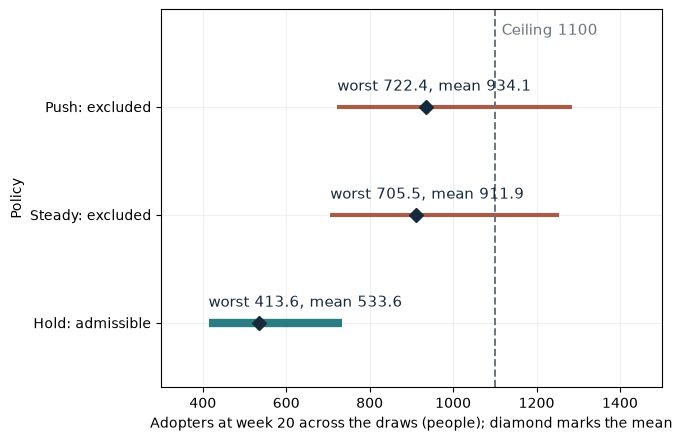

- **Push: mean, worst case:** 934.1, 722.4
- **Push: draws above the ceiling:** 4 of 25
- **Steady: mean, worst case:** 911.9, 705.5
- **Steady: draws above the ceiling:** 4 of 25
- **Hold: mean, worst case:** 533.6, 413.6
- **Hold: draws above the ceiling:** 0 of 25
- **Recommendation:** Hold

Push has the best mean, 934.1, but its highest draw 1285.6 - 1100 = 185.6 breaches the ceiling in 4 of 25 draws, so it is excluded. Recommended: Hold, worst case 413.6, mean 533.6. Mean given up: 934.1 - 533.6 = 400.5 adopters. Ranking is by worst case among the admissible policies.

In [12]:
show(best_average(ceiling=1100.0, draws=25))

**Use the idea.** Declare the ceiling and its reason before running the search, so an exclusion cannot be argued away afterwards.

**Where the conclusion applies.** Three named policies, one uncertain quantity, seed 7. The result changes with the number of draws, because fewer draws may miss the draws that breach.

*Constructed example: the chapter's three policies, 25 draws and seed 7, with other ceilings and draw counts defined for this reader, compared by the chapter's compare and recommend functions.*

Every setting the interactive reader offers for this demonstration:

In [13]:
sweep(best_average, [('ceiling', [1000.0, 1100.0, 1300.0]), ('draws', [10, 25])])

- **ceiling = 1000.0, draws = 10**: Push: mean, worst case 888.0, 722.4; Push: draws above the ceiling 3 of 10; Steady: mean, worst case 867.0, 705.5; Steady: draws above the ceiling 1 of 10; Hold: mean, worst case 507.5, 413.6; Hold: draws above the ceiling 0 of 10; Recommendation Hold
- **ceiling = 1000.0, draws = 25**: Push: mean, worst case 934.1, 722.4; Push: draws above the ceiling 9 of 25; Steady: mean, worst case 911.9, 705.5; Steady: draws above the ceiling 7 of 25; Hold: mean, worst case 533.6, 413.6; Hold: draws above the ceiling 0 of 25; Recommendation Hold
- **ceiling = 1100.0, draws = 10**: Push: mean, worst case 888.0, 722.4; Push: draws above the ceiling 0 of 10; Steady: mean, worst case 867.0, 705.5; Steady: draws above the ceiling 0 of 10; Hold: mean, worst case 507.5, 413.6; Hold: draws above the ceiling 0 of 10; Recommendation Push
- **ceiling = 1100.0, draws = 25**: Push: mean, worst case 934.1, 722.4; Push: draws above the ceiling 4 of 25; Steady: mean, worst case 911.9, 705.5; Steady: draws above the ceiling 4 of 25; Hold: mean, worst case 533.6, 413.6; Hold: draws above the ceiling 0 of 25; Recommendation Hold
- **ceiling = 1300.0, draws = 10**: Push: mean, worst case 888.0, 722.4; Push: draws above the ceiling 0 of 10; Steady: mean, worst case 867.0, 705.5; Steady: draws above the ceiling 0 of 10; Hold: mean, worst case 507.5, 413.6; Hold: draws above the ceiling 0 of 10; Recommendation Push
- **ceiling = 1300.0, draws = 25**: Push: mean, worst case 934.1, 722.4; Push: draws above the ceiling 0 of 25; Steady: mean, worst case 911.9, 705.5; Steady: draws above the ceiling 0 of 25; Hold: mean, worst case 533.6, 413.6; Hold: draws above the ceiling 0 of 25; Recommendation Push

## 2. Every draw, not the average

*What changes when a ceiling is checked on the average instead of on every draw?*

A mean can sit well below a ceiling that some draws exceed. Checking the average lets a policy pass that breaches in the worlds where the ceiling is reached.

    draw 13: adopters=1196 above 1100.0 (support capacity ceiling)

**Symbols and inputs.** The ceiling is a bound on adopters. Judged on every draw, one breach excludes a policy. Judged on the average, only the mean is compared with the ceiling.

**Predict first.** At a ceiling of 1100, which policy does the average-based check recommend?

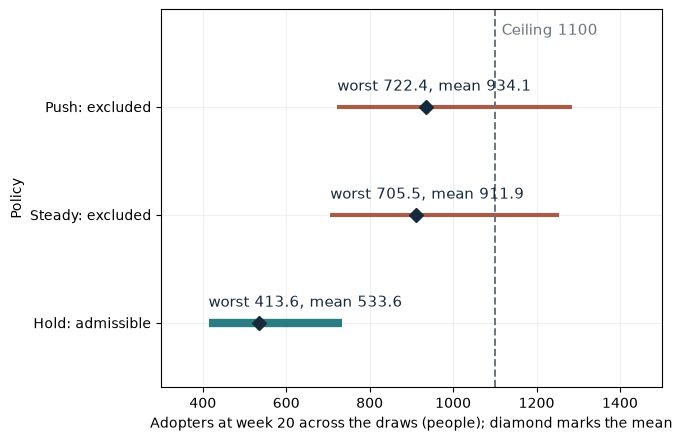

- **Judged on:** every draw
- **Push:** excluded
- **Steady:** excluded
- **Hold:** admissible
- **Recommendation:** Hold
- **First violation message:** draw 13: adopters=1196 above 1100.0 (support capacity ceiling)

On every draw, push goes above 1100 in 4 of 25 draws (highest 1285.6 - 1100 = 185.6). Recommended: Hold, worst case 413.6, mean 533.6.

In [14]:
show(draw_or_average(ceiling=1100.0, check='draw'))

**Use the idea.** Write the constraint to be checked on every draw, because a capacity is exceeded on the days it is exceeded.

**Where the conclusion applies.** Twenty-five draws of one uncertain quantity. A ceiling above every draw cannot distinguish the two checks.

*Constructed example: the chapter's policies, draws and 1100 ceiling, with other ceilings defined for this reader, judged with the chapter's Bound and recommend.*

Every setting the interactive reader offers for this demonstration:

In [15]:
sweep(draw_or_average, [('ceiling', [900.0, 1100.0, 1300.0]), ('check', ['draw', 'average'])])

- **ceiling = 900.0, check = draw**: Judged on every draw; Push excluded; Steady excluded; Hold admissible; Recommendation Hold; First violation message draw 2: adopters=1090 above 900.0 (support capacity ceiling)
- **ceiling = 900.0, check = average**: Judged on the average; Push excluded; Steady excluded; Hold admissible; Recommendation Hold; First violation message adopters=934.1 above 900.0 (support capacity ceiling)
- **ceiling = 1100.0, check = draw**: Judged on every draw; Push excluded; Steady excluded; Hold admissible; Recommendation Hold; First violation message draw 13: adopters=1196 above 1100.0 (support capacity ceiling)
- **ceiling = 1100.0, check = average**: Judged on the average; Push admissible; Steady admissible; Hold admissible; Recommendation Push; First violation message none
- **ceiling = 1300.0, check = draw**: Judged on every draw; Push admissible; Steady admissible; Hold admissible; Recommendation Push; First violation message none
- **ceiling = 1300.0, check = average**: Judged on the average; Push admissible; Steady admissible; Hold admissible; Recommendation Push; First violation message none

## 3. Same draws, every policy

*Can two close policies be compared on different draws?*

Different draws mean different markets, and the market moves adopters by more than the policies' gap. On shared draws the same markets meet both policies, so the gap belongs to the policies.

    compare(document, policies, uncertainties, "adopters", bounds, draws=25, seed=7, settings=RunSettings(dt=1.0, horizon=20.0))

**Symbols and inputs.** Push and steady differ in word-of-mouth strength, 0.55 and 0.35. Each is evaluated on market-size draws from its seed.

**Predict first.** With 5 draws each and a different seed for steady, can steady read ahead of push?

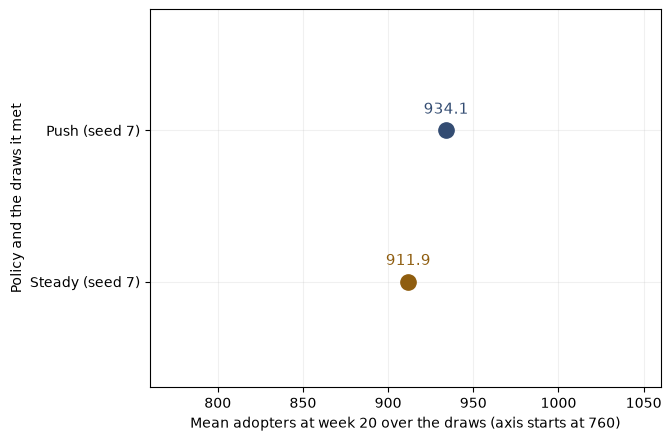

- **Draws:** 25
- **Draw design:** shared seed 7
- **Push mean:** 934.1
- **Steady mean:** 911.9
- **Push minus steady:** 22.2

Push minus steady = 934.1 - 911.9 = 22.2. Push reads ahead. With shared draws the same 25 markets meet both policies, so the gap is the policies' alone.

In [16]:
show(shared_draws(draws=25, design='shared'))

**Use the idea.** Keep the seed in the run settings so a comparison can be repeated with the same draws.

**Where the conclusion applies.** Two policies, a few seeds chosen for this reader. Whether a given pair of seeds reverses the order is a property of those seeds, not a rate.

*Constructed example: the chapter's push and steady policies on its market-size range, with separate seeds defined for this reader, run with the chapter's evaluate function.*

Every setting the interactive reader offers for this demonstration:

In [17]:
sweep(shared_draws, [('draws', [5, 25]), ('design', ['shared', 's8', 's9', 's10'])])

- **draws = 5, design = shared**: Draws 5; Draw design shared seed 7; Push mean 907.9; Steady mean 886.4; Push minus steady 21.6
- **draws = 5, design = s8**: Draws 5; Draw design separate seeds, 7 and 8; Push mean 907.9; Steady mean 929.8; Push minus steady (-21.9)
- **draws = 5, design = s9**: Draws 5; Draw design separate seeds, 7 and 9; Push mean 907.9; Steady mean 899.7; Push minus steady 8.2
- **draws = 5, design = s10**: Draws 5; Draw design separate seeds, 7 and 10; Push mean 907.9; Steady mean 987.4; Push minus steady (-79.5)
- **draws = 25, design = shared**: Draws 25; Draw design shared seed 7; Push mean 934.1; Steady mean 911.9; Push minus steady 22.2
- **draws = 25, design = s8**: Draws 25; Draw design separate seeds, 7 and 8; Push mean 934.1; Steady mean 925.9; Push minus steady 8.2
- **draws = 25, design = s9**: Draws 25; Draw design separate seeds, 7 and 9; Push mean 934.1; Steady mean 948.7; Push minus steady (-14.6)
- **draws = 25, design = s10**: Draws 25; Draw design separate seeds, 7 and 10; Push mean 934.1; Steady mean 1006.8; Push minus steady (-72.8)

## 4. When no policy is admissible

*What does the search return when every candidate breaks a constraint?*

Both breach the ceiling, so the search returns nothing. Adding a lower-risk policy to the candidate set can restore an option; a ceiling below every draw of every policy cannot be met.

    recommend(evaluations)

**Symbols and inputs.** A candidate set is the policies somebody proposed. The ceiling is a bound on adopters, checked on all 25 draws.

**Predict first.** With only push and steady as candidates and a ceiling of 1100, does the search recommend either?

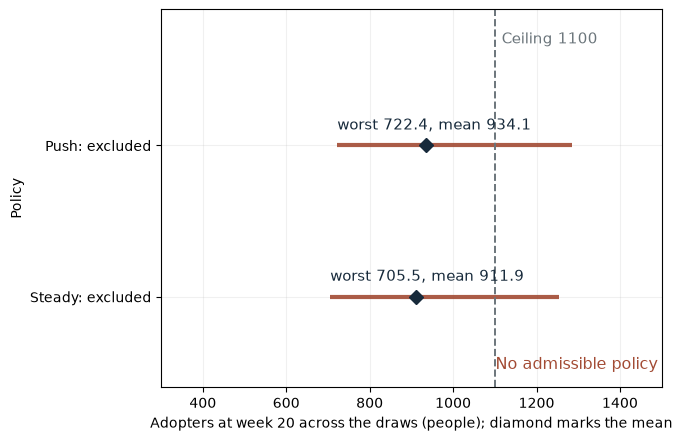

- **Candidates:** Push, Steady
- **Ceiling:** 1100
- **Push: draws above the ceiling:** 4 of 25
- **Steady: draws above the ceiling:** 4 of 25
- **Recommendation:** none: every policy violated a stated constraint

Highest draw minus the ceiling: Push 1285.6 - 1100 = 185.6; Steady 1254.6 - 1100 = 154.6. A positive result is a breach. Every policy violated a stated constraint, so the search returns no recommendation. The response is a decision: widen the candidate set, restate the constraint in the open, or report that no option is acceptable.

In [18]:
show(no_admissible(candidates='two', ceiling=1100.0))

**Use the idea.** Treat an empty recommendation as a finding: widen the candidates, restate the constraint in the open, or report that no option is acceptable.

**Where the conclusion applies.** Policies are fixed settings and the ceiling is fixed. The failure to avoid is quietly relaxing the ceiling to get an answer.

*Constructed example: the chapter's policies and seed, with the ceilings and candidate sets defined for this reader, searched with the chapter's recommend function.*

Every setting the interactive reader offers for this demonstration:

In [19]:
sweep(no_admissible, [('candidates', ['two', 'three']), ('ceiling', [600.0, 800.0, 1100.0])])

- **candidates = two, ceiling = 600.0**: Candidates Push, Steady; Ceiling 600; Push: draws above the ceiling 25 of 25; Steady: draws above the ceiling 25 of 25; Recommendation none: every policy violated a stated constraint
- **candidates = two, ceiling = 800.0**: Candidates Push, Steady; Ceiling 800; Push: draws above the ceiling 16 of 25; Steady: draws above the ceiling 16 of 25; Recommendation none: every policy violated a stated constraint
- **candidates = two, ceiling = 1100.0**: Candidates Push, Steady; Ceiling 1100; Push: draws above the ceiling 4 of 25; Steady: draws above the ceiling 4 of 25; Recommendation none: every policy violated a stated constraint
- **candidates = three, ceiling = 600.0**: Candidates Push, Steady, Hold; Ceiling 600; Push: draws above the ceiling 25 of 25; Steady: draws above the ceiling 25 of 25; Hold: draws above the ceiling 6 of 25; Recommendation none: every policy violated a stated constraint
- **candidates = three, ceiling = 800.0**: Candidates Push, Steady, Hold; Ceiling 800; Push: draws above the ceiling 16 of 25; Steady: draws above the ceiling 16 of 25; Hold: draws above the ceiling 0 of 25; Recommendation Hold
- **candidates = three, ceiling = 1100.0**: Candidates Push, Steady, Hold; Ceiling 1100; Push: draws above the ceiling 4 of 25; Steady: draws above the ceiling 4 of 25; Hold: draws above the ceiling 0 of 25; Recommendation Hold

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

At a ceiling of 1300 with 25 draws, which policy is recommended?

<details><summary>Answer</summary>

Push. Its highest draw is 1285.6, which is below 1300, so no policy is excluded, and push has the best worst case, 722.4.

</details>

### Exercise 2

At a ceiling of 900, does push pass the average-based check?

<details><summary>Answer</summary>

No. Its mean is 934.1, and 934.1 - 900 = 34.1 is above the ceiling, so it fails either way.

</details>

### Exercise 3

On shared draws with 25 draws, which policy has the higher mean, and by how much?

<details><summary>Answer</summary>

Push, by 934.1 - 911.9 = 22.2.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/